# 🧪 TP pratique : diagnostiquer et préparer des données

**Durée indicative : 2 h 30 — Niveau : initiation avec bases de Python.**

## Objectifs observables

À la fin du TP, vous devez pouvoir :

1. typer les variables et quantifier les valeurs manquantes ;
2. séparer entraînement et test avant toute transformation apprise ;
3. construire un `ColumnTransformer` robuste aux catégories inconnues ;
4. contrôler automatiquement les formes, valeurs manquantes et valeurs infinies ;
5. distinguer association exploratoire et preuve de performance prédictive.

Exécutez les cellules dans l'ordre. Les cellules **À vous de jouer** sont volontairement valides mais incomplètes ; écrivez votre réponse avant d'ouvrir la solution.


## 1. Importation des bibliothèques et initialisation

Nous importons ici les outils standards de la science des données en Python :
- **NumPy** : Calcul numérique vectoriel ultra-rapide.
- **Pandas** : Manipulation de tableaux de données (DataFrames, équivalent d'Excel en Python).
- **Matplotlib & Seaborn** : Visualisation graphique de nos distributions.
- **Scikit-Learn (sklearn)** : La bibliothèque de référence pour le Machine Learning et le prétraitement.

In [1]:
# Bibliothèques de calcul et manipulation de données
import numpy as np
import pandas as pd
from IPython.display import display

# Bibliothèques de visualisation graphique
import matplotlib.pyplot as plt
import seaborn as sns

# Modules Scikit-Learn pour le découpage et le prétraitement
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder

# Configuration visuelle des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
print("✅ Toutes les bibliothèques sont importées avec succès !")


✅ Toutes les bibliothèques sont importées avec succès !


## 2. Génération d'un jeu de données brut réaliste

Pour apprendre concrètement, nous simulons un cas d'usage bancaire réel : **l'octroi d'un crédit**.
Nous avons 1 200 clients, et nous voulons prédire la cible `defaut_paiement` (1 = le client n'a pas remboursé, 0 = le client a remboursé normalement).

Nous injectons volontairement les anomalies typiques du monde réel :
- Des **cases vides (`NaN`)** dans le revenu et le statut marital.
- Des **valeurs aberrantes (*outliers*)** (ex: une erreur de saisie avec un revenu négatif de -5 000 €, ou un revenu géant de 1 500 000 €).
- Du texte catégoriel (`statut_marital`, `secteur_activite`, `niveau_education`).

In [2]:
rng = np.random.default_rng(42)
n_samples = 1200

# Variables quantitatives latentes, avant les erreurs de saisie.
revenu_propre = rng.normal(loc=45_000, scale=15_000, size=n_samples)
revenu_propre = np.clip(revenu_propre, 8_000, None)
montant_credit_propre = rng.exponential(scale=20_000, size=n_samples) + 5_000
score_credit = rng.integers(300, 850, size=n_samples).astype(float)
anciennete_emploi = rng.poisson(lam=5, size=n_samples).astype(float)

statuts = rng.choice(
    ['Célibataire', 'Marié', 'Divorcé'], size=n_samples, p=[0.45, 0.45, 0.10]
)
secteurs = rng.choice(
    ['Technologie', 'Santé', 'Finance', 'Commerce', 'Industrie'], size=n_samples
)
educations = rng.choice(
    ['Secondaire', 'Licence', 'Master', 'Doctorat'],
    size=n_samples,
    p=[0.30, 0.40, 0.25, 0.05],
)

# La cible est créée à partir des valeurs plausibles, avant l'injection des anomalies.
score_risque = (
    (600 - score_credit) / 80
    + montant_credit_propre / revenu_propre
    - 1.5
)
prob_defaut = 1 / (1 + np.exp(-np.clip(score_risque, -30, 30)))
defaut = (rng.random(n_samples) < prob_defaut).astype(int)

# Copie observée puis injection d'erreurs de saisie et de cas extrêmes.
revenu_annuel = revenu_propre.copy()
montant_credit = montant_credit_propre.copy()
revenu_annuel[0] = 1_500_000
revenu_annuel[1] = -5_000
montant_credit[2] = 450_000

df = pd.DataFrame({
    'revenu_annuel': revenu_annuel,
    'montant_credit': montant_credit,
    'score_credit': score_credit,
    'anciennete_emploi': anciennete_emploi,
    'statut_marital': statuts,
    'secteur_activite': secteurs,
    'niveau_education': educations,
    'defaut_paiement': defaut,
})

# Valeurs manquantes MCAR simulées pour l'exercice.
df.loc[rng.random(n_samples) < 0.08, 'revenu_annuel'] = np.nan
df.loc[rng.random(n_samples) < 0.05, 'statut_marital'] = np.nan

print(f"Jeu créé : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
display(df.head())


Jeu créé : 1200 lignes et 8 colonnes.


,revenu_annuel,montant_credit,score_credit,anciennete_emploi,statut_marital,secteur_activite,niveau_education,defaut_paiement
0,NaN,8532.479150,805.0,3.0,Célibataire,Santé,Secondaire,0
1,-5000.000000,24356.499963,819.0,9.0,Célibataire,Santé,Licence,0
2,56256.767937,450000.000000,509.0,3.0,Marié,Commerce,Secondaire,1
3,59108.470746,16323.056710,577.0,4.0,Célibataire,Santé,Secondaire,1
4,15734.472170,27865.542045,842.0,8.0,Célibataire,Santé,Master,0


## 3. Exploration et Diagnostic des Données (EDA)

Avant toute transformation, nous devons inspecter :
1. Le type des variables (`dtypes`).
2. Le taux de valeurs manquantes par colonne.
3. Les statistiques descriptives de base (`describe()`).


In [3]:
# Résumé technique et valeurs manquantes
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs_Manquantes': df.isna().sum(),
    'Pourcentage_NaN (%)': (df.isna().sum() / len(df) * 100).round(2)
})
print("--- Diagnostic des colonnes et valeurs manquantes ---")
display(info_df)


--- Diagnostic des colonnes et valeurs manquantes ---


,Type,Valeurs_Manquantes,Pourcentage_NaN (%)
revenu_annuel,float64,89,7.42
montant_credit,float64,0,0.00
score_credit,float64,0,0.00
anciennete_emploi,float64,0,0.00
statut_marital,str,64,5.33
secteur_activite,str,0,0.00
niveau_education,str,0,0.00
defaut_paiement,int64,0,0.00


In [4]:
# Statistiques descriptives
df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]


,count,mean,std,min,50%,max
revenu_annuel,1111.0,44610.044935,14826.046120,-5000.00000,44971.202202,92682.805191
montant_credit,1200.0,25875.080249,24506.474909,5009.68456,19054.852482,450000.000000
score_credit,1200.0,574.929167,155.992496,300.00000,579.500000,849.000000
anciennete_emploi,1200.0,4.920833,2.307380,0.00000,5.000000,14.000000
defaut_paiement,1200.0,0.416667,0.493212,0.00000,0.000000,1.000000


Visualisons la distribution du `revenu_annuel` pour observer l'effet des valeurs aberrantes :


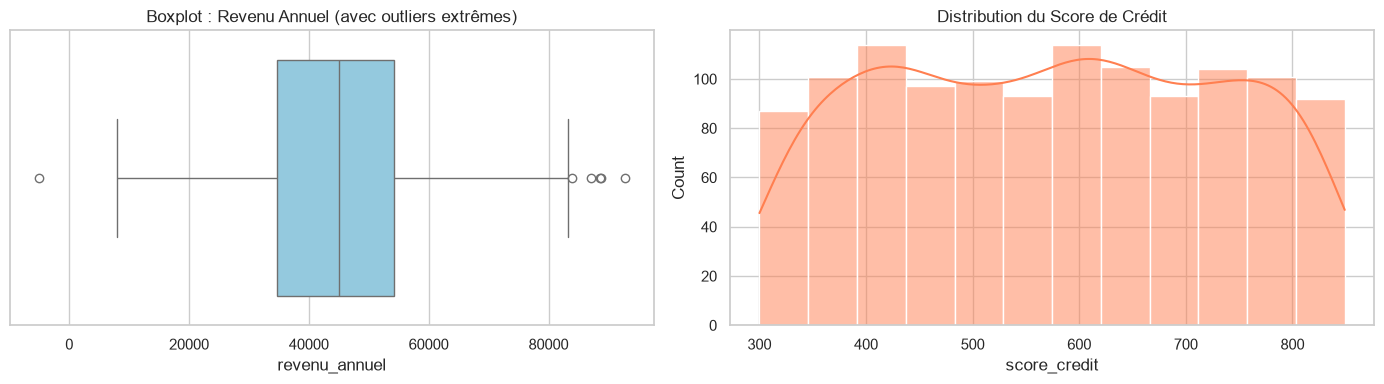

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df['revenu_annuel'], ax=axes[0], color='skyblue')
axes[0].set_title("Boxplot : Revenu Annuel (avec outliers extrêmes)")

sns.histplot(df['score_credit'], kde=True, ax=axes[1], color='coral')
axes[1].set_title("Distribution du Score de Crédit")
plt.tight_layout()
plt.show()


## 4. Séparation stricte entraînement / test

> **Règle de validation** : le test ne doit influencer ni l'imputation, ni la mise à l'échelle, ni le choix des variables ou hyperparamètres.
>
> `stratify=y` vise à conserver des proportions de classes proches dans les deux ensembles. Elles ne sont pas nécessairement identiques au centième près.


In [6]:
# Définition des features X et de la cible y
X = df.drop(columns=['defaut_paiement'])
y = df['defaut_paiement']

# Découpage stratifié pour conserver la proportion de la classe cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Taille du Train set : {X_train.shape}")
print(f"Taille du Test set  : {X_test.shape}")
print(f"Taux de défaut dans Train : {y_train.mean():.2%}")
print(f"Taux de défaut dans Test  : {y_test.mean():.2%}")


Taille du Train set : (960, 7)
Taille du Test set  : (240, 7)
Taux de défaut dans Train : 41.67%
Taux de défaut dans Test  : 41.67%


## 5. Construction du Préprocesseur avec `ColumnTransformer`

Chaque type de colonne nécessite un traitement sur-mesure :
1. **Numériques (`num_cols`)** : On bouche les cases vides avec la **médiane** (insensible aux erreurs de saisie) puis on utilise `RobustScaler` (mise à l'échelle robuste basée sur les quartiles).
2. **Catégorielles Nominales (`cat_nominal_cols`)** : Sans ordre (ex: Statut marital). On bouche les trous par la valeur la plus fréquente, puis on applique un **One-Hot Encoding** (`handle_unknown='ignore'` pour ne pas crasher si une nouvelle catégorie apparaît en production).
3. **Catégorielles Ordinales (`cat_ordinal_cols`)** : Avec ordre hiérarchique strict (`Secondaire` < `Licence` < `Master` < `Doctorat`). On encode en entiers `0, 1, 2, 3` respectant cet ordre.

In [7]:
num_cols = ['revenu_annuel', 'montant_credit', 'score_credit', 'anciennete_emploi']
cat_nominal_cols = ['statut_marital', 'secteur_activite']
cat_ordinal_cols = ['niveau_education']
ordre_education = [['Secondaire', 'Licence', 'Master', 'Doctorat']]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=ordre_education,
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('nominal', nominal_pipeline, cat_nominal_cols),
    ('ordinal', ordinal_pipeline, cat_ordinal_cols),
])

print("Préprocesseur configuré.")


Préprocesseur configuré.


## 6. Ajustement (`fit`) et Transformation (`transform`)

Observons l'étanchéité :
- `preprocessor.fit(X_train)` apprend les paramètres statistiques (médianes, quantiles, modalités) uniquement sur `X_train`.
- `preprocessor.transform(X_train)` et `preprocessor.transform(X_test)` appliquent ces règles apprises.


In [8]:
# Le fit n'utilise que l'entraînement ; le test reçoit uniquement transform.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

df_train_ready = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index,
)

assert X_train.index.intersection(X_test.index).empty
assert X_train_processed.shape[0] == len(X_train)
assert X_test_processed.shape[1] == X_train_processed.shape[1]
assert np.isfinite(X_train_processed).all()
assert np.isfinite(X_test_processed).all()

print("Dimensions entraînement :", X_train_processed.shape)
print("Dimensions test          :", X_test_processed.shape)
print("Contrôles réussis : ensembles disjoints, mêmes colonnes, valeurs finies.")
display(df_train_ready.head())


Dimensions entraînement : (960, 13)
Dimensions test          : (240, 13)
Contrôles réussis : ensembles disjoints, mêmes colonnes, valeurs finies.


,num__revenu_annuel,num__montant_credit,num__score_credit,num__anciennete_emploi,nominal__statut_marital_Célibataire,nominal__statut_marital_Divorcé,nominal__statut_marital_Marié,nominal__secteur_activite_Commerce,nominal__secteur_activite_Finance,nominal__secteur_activite_Industrie,nominal__secteur_activite_Santé,nominal__secteur_activite_Technologie,ordinal__niveau_education
1132,-0.624706,1.237669,-0.594348,0.333333,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1049,0.377282,-0.617937,0.481313,-0.333333,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
106,-0.860332,1.829337,0.014585,-0.666667,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1184,-0.022447,0.500660,0.051048,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
347,0.514102,-0.312409,0.616226,1.333333,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## 7. Exercice guidé : créer un ratio sans consulter le test

### Énoncé

1. Travaillez uniquement sur `X_train` et `y_train`.
2. Créez `ratio_endettement = montant_credit / revenu_annuel` seulement lorsque le revenu est strictement positif.
3. Calculez les corrélations de Pearson avec `defaut_paiement`.
4. Expliquez en une phrase pourquoi une corrélation ne prouve ni causalité ni gain prédictif sur le test.

**Critère de réussite** : aucun indice de test n'est utilisé et aucun ratio infini n'est produit.


In [9]:
# À vous de jouer — complétez avant d'exécuter la solution.
train_exploration = X_train.copy()
# TODO : ajouter la cible, construire le ratio et calculer les corrélations.


ratio_endettement    0.175222
montant_credit       0.161319
revenu_annuel       -0.087684
Name: corrélation, dtype: float64

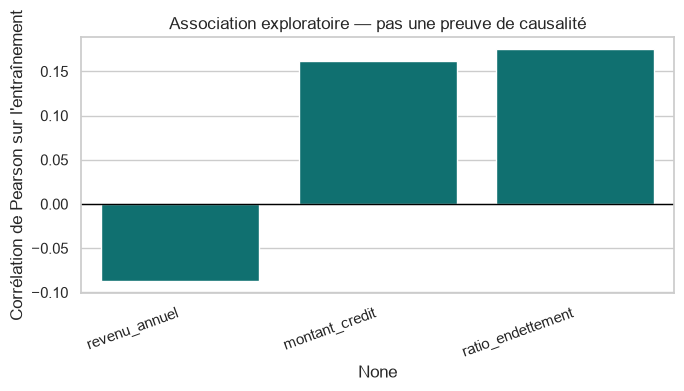

Interprétation : ce classement décrit l'échantillon d'entraînement. Il faut intégrer le ratio dans un pipeline et mesurer le gain sur validation avant de conclure à une utilité prédictive.


In [10]:
# Solution
train_exploration = X_train.copy()
train_exploration['defaut_paiement'] = y_train

revenu_valide = train_exploration['revenu_annuel'].where(
    train_exploration['revenu_annuel'] > 0
)
train_exploration['ratio_endettement'] = (
    train_exploration['montant_credit'] / revenu_valide
)

variables = [
    'revenu_annuel',
    'montant_credit',
    'ratio_endettement',
    'defaut_paiement',
]
correlations = train_exploration[variables].corr()['defaut_paiement'].drop(
    'defaut_paiement'
)

assert not np.isinf(train_exploration['ratio_endettement'].dropna()).any()
assert set(train_exploration.index) == set(X_train.index)

display(correlations.sort_values(ascending=False).rename('corrélation'))
plt.figure(figsize=(7, 4))
sns.barplot(x=correlations.index, y=correlations.values, color='teal')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=20, ha='right')
plt.ylabel("Corrélation de Pearson sur l'entraînement")
plt.title("Association exploratoire — pas une preuve de causalité")
plt.tight_layout()
plt.show()

print(
    "Interprétation : ce classement décrit l'échantillon d'entraînement. "
    "Il faut intégrer le ratio dans un pipeline et mesurer le gain sur validation "
    "avant de conclure à une utilité prédictive."
)


## Conclusion et auto-évaluation

Vous devez maintenant savoir expliquer :

1. pourquoi les transformations apprises sont ajustées uniquement sur l'entraînement ;
2. comment `ColumnTransformer` applique des traitements différents selon la nature des colonnes ;
3. pourquoi un contrôle de valeurs finies et de formes fait partie du pipeline ;
4. pourquoi une corrélation calculée sur le train reste une piste à valider, pas une conclusion causale.
